In [ ]:
import pandas as pd

In [ ]:
game_chat = pd.read_csv('game_chat.csv')

In [ ]:
print(game_chat.loc[0:3, 'radiant_chat'])

0          потренируйся с ботами????
1                                NaN
2    u just buy levels blue? | fa ge
3                                NaN
Name: radiant_chat, dtype: object


In [ ]:
game_chat.columns

Index(['match_id', 'radiant_chat', 'dire_chat'], dtype='object')

In [ ]:
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from functools import lru_cache
import pymorphy2
import re

tt = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=True)
morph = pymorphy2.MorphAnalyzer()
stop_words = set(stopwords.words("russian"))


@lru_cache(maxsize=50000)
def lemmatize(word):
    return morph.parse(word)[0].normal_form

def preprocessing(text):
    text = text.lower()
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    tokens = tt.tokenize(text)
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    lemmas = [lemmatize(t) for t in tokens]
    return lemmas


print(preprocessing("Ляяя, ваша мама такая красивая, ну вылитый пудж)))0"))

['ляя', 'ваш', 'мама', 'такой', 'красивый', 'вылитый', 'пуджа']


/home/kosow/miniforge3/envs/rapids/lib/python3.10/site-packages/pymorphy2/analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
import pandas as pd
import numpy as np

def add_chat_feature(df_train, df_test, game_chat):

    game_chat_train = game_chat[game_chat['match_id'].isin(df_train['match_id'])].copy()
    game_chat_test = game_chat[game_chat['match_id'].isin(df_test['match_id'])].copy()
    game_chat_train = game_chat_train.fillna('')
    game_chat_test = game_chat_test.fillna('')

    game_chat_train = game_chat_train.sort_values('match_id')
    game_chat_test = game_chat_test.sort_values('match_id')

    tfidf_r = TfidfVectorizer(tokenizer=preprocessing, max_features=3000)
    tfidf_d = TfidfVectorizer(tokenizer=preprocessing, max_features=3000)

    Xr_train_sparse = tfidf_r.fit_transform(game_chat_train['radiant_chat'])
    Xd_train_sparse = tfidf_d.fit_transform(game_chat_train['dire_chat'])
    Xr_test_sparse = tfidf_r.transform(game_chat_test['radiant_chat'])
    Xd_test_sparse = tfidf_d.transform(game_chat_test['dire_chat'])

    train_match_ids = game_chat_train['match_id'].values
    test_match_ids = game_chat_test['match_id'].values

    return Xr_train_sparse, Xd_train_sparse, Xr_test_sparse, Xd_test_sparse, train_match_ids, test_match_ids

In [ ]:
matches_df_train = pd.read_csv("matches_df_train.csv")
matches_df_test = pd.read_csv("matches_df_test.csv")
game_chat = pd.read_csv('game_chat.csv')
add_chat_feature(matches_df_train, matches_df_test, game_chat)

/home/kosow/miniforge3/envs/rapids/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


2


In [ ]:
dota_adv = pd.read_csv("dota_adv.csv")
dota_adv.columns

Index(['match_id', 'radiant_gold_adv', 'radiant_exp_adv'], dtype='object')

In [ ]:
dota_adv.dtypes

match_id             int64
radiant_gold_adv    object
radiant_exp_adv     object
dtype: object

In [ ]:
dota_adv['radiant_gold_adv'].head(3)

0    [   0  159  452 1904 2100 3290 3290 3290 3290 ...
1    [   0 -151 -141   12 -165 -151 -151    4  377 ...
2                                                   []
Name: radiant_gold_adv, dtype: object

In [ ]:
def str_to_list(s):
    if pd.isna(s) or s in ["[]", ""]:
        return []
    return [float(x) for x in s.strip("[]").split() if x]

dota_adv['radiant_gold_adv'] = dota_adv['radiant_gold_adv'].apply(str_to_list)
dota_adv['radiant_exp_adv'] = dota_adv['radiant_exp_adv'].apply(str_to_list)

In [ ]:
print(dota_adv['radiant_gold_adv'].apply(len).eq(0).sum())
print(dota_adv['radiant_exp_adv'].apply(len).eq(0).sum())

529783
529783


In [ ]:
dota_adv.shape[0]

767822

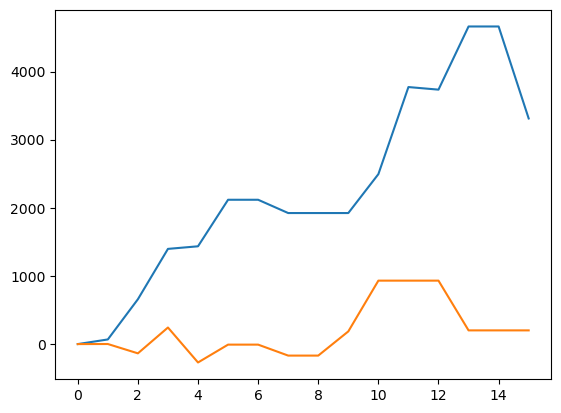

In [ ]:
import matplotlib.pyplot as plt

plt.plot(dota_adv['radiant_exp_adv'][0])
plt.plot(dota_adv['radiant_exp_adv'][1])

'[   0  159  452 1904 2100 3290 3290 3290 3290 3859 3859 3087 3087 3849\n 5342 5342]'

In [ ]:
def add_adv_feature(df_train, df_test, dota_adv):
    dota_adv['is_missin_gold'] = dota_adv['radiant_gold_adv'].apply(lambda row: 1 if len(row) == 0 else 0)
    dota_adv['is_missin_exp'] = dota_adv['radiant_exp_adv'].apply(lambda row: 1 if len(row) == 0 else 0)

    dota_adv['gold_mean'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.mean(x) if len(x) > 0 else 0)
    dota_adv['gold_sum'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.sum(x) if len(x) > 0 else 0)
    dota_adv['gold_std'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.std(x) if len(x) > 0 else 0)
    dota_adv['gold_last'] = dota_adv['radiant_gold_adv'].apply(lambda x: x[-1] if len(x) > 0 else 0)
    dota_adv['gold_first'] = dota_adv['radiant_gold_adv'].apply(lambda x: x[0] if len(x) > 0 else 0)

    dota_adv['exp_mean'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.mean(x) if len(x) > 0 else 0)
    dota_adv['exp_sum'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.sum(x) if len(x) > 0 else 0)
    dota_adv['exp_std'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.std(x) if len(x) > 0 else 0)
    dota_adv['exp_last'] = dota_adv['radiant_exp_adv'].apply(lambda x: x[-1] if len(x) > 0 else 0)
    dota_adv['exp_first'] = dota_adv['radiant_exp_adv'].apply(lambda x: x[0] if len(x) > 0 else 0)


    df_train = df_train.merge(dota_adv, on='match_id', how='left')
    df_test = df_test.merge(dota_adv, on='match_id', how='left')

    return df_train, df_test




In [ ]:
def radiant(numbers):
    res = [x for x in numbers if x > 0]
    return np.std(res) if numbers else 0

def dire(numbers):
    res = [abs(x) for x in numbers if x < 0]
    return np.std(res) if numbers else 0

def add_adv_feature(df_train, df_test, dota_adv):
    dota_adv['is_missin_gold'] = dota_adv['radiant_gold_adv'].apply(lambda row: 1 if len(row) == 0 else 0)
    dota_adv['is_missin_exp'] = dota_adv['radiant_exp_adv'].apply(lambda row: 1 if len(row) == 0 else 0)

    dota_adv['gold_mean'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.mean(x) if len(x) > 0 else 0)
    dota_adv['gold_sum'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.sum(x) if len(x) > 0 else 0)
    dota_adv['gold_std_d'] = dota_adv['radiant_gold_adv'].apply(lambda x: dire(x))
    dota_adv['gold_std_r'] = dota_adv['radiant_gold_adv'].apply(lambda x: radiant(x))
    dota_adv['gold_last'] = dota_adv['radiant_gold_adv'].apply(lambda x: x[-1] if len(x) > 0 else 0)
    dota_adv['gold_first'] = dota_adv['radiant_gold_adv'].apply(lambda x: x[0] if len(x) > 0 else 0)

    dota_adv['gold_mean_early'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.mean(x[0:5]) if len(x) > 0 else 0)
    dota_adv['gold_mean_mid'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.mean(x[5:10]) if len(x) > 0 else 0)
    dota_adv['gold_mean_late'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.mean(x[10:16]) if len(x) > 0 else 0)

    dota_adv['exp_mean'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.mean(x) if len(x) > 0 else 0)
    dota_adv['exp_sum'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.sum(x) if len(x) > 0 else 0)
    dota_adv['exp_std_d'] = dota_adv['radiant_gold_adv'].apply(lambda x: dire(x))
    dota_adv['exp_std_r'] = dota_adv['radiant_gold_adv'].apply(lambda x: radiant(x))
    dota_adv['exp_last'] = dota_adv['radiant_exp_adv'].apply(lambda x: x[-1] if len(x) > 0 else 0)
    dota_adv['exp_first'] = dota_adv['radiant_exp_adv'].apply(lambda x: x[0] if len(x) > 0 else 0)

    dota_adv['exp_mean_early'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.mean(x[0:5]) if len(x) > 0 else 0)
    dota_adv['exp_mean_mid'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.mean(x[5:10]) if len(x) > 0 else 0)
    dota_adv['exp_mean_late'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.mean(x[10:16]) if len(x) > 0 else 0)


    df_train = df_train.merge(dota_adv, on='match_id', how='left')
    df_test = df_test.merge(dota_adv, on='match_id', how='left')

    return df_train, df_test

In [ ]:
print("Bспользую ниже в пайплайне")
print("после добавления фичи с простыми  часть 1, gini при сабмишине показал:",  0.38529)
print("после добавления фичи с сложной  часть 2, gini при сабмишине показал:",  0.38763)

Bспользую ниже в пайплайне
после добавления фичи с простыми  часть 1, gini при сабмишине показал: 0.38529


In [ ]:
def str_to_list(s):
        if pd.isna(s) or s in ["[]", ""]:
            return []
        return [float(x) for x in s.strip("[]").split() if x]


In [ ]:
def radiant(numbers):
    res = [x for x in numbers if x > 0]
    return np.std(res) if numbers else 0



def add_adv_feature(df_train, df_test, dota_adv):
    dota_adv['is_missin_gold'] = dota_adv['radiant_gold_adv'].apply(lambda row: 1 if len(row) == 0 else 0)
    dota_adv['is_missin_exp'] = dota_adv['radiant_exp_adv'].apply(lambda row: 1 if len(row) == 0 else 0)

    dota_adv['gold_mean'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.mean(x) if len(x) > 0 else 0)
    dota_adv['gold_sum'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.sum(x) if len(x) > 0 else 0)
    dota_adv['gold_std_d'] = dota_adv['radiant_gold_adv'].apply(lambda x: dire(x))
    dota_adv['gold_std_r'] = dota_adv['radiant_gold_adv'].apply(lambda x: radiant(x))
    dota_adv['gold_last'] = dota_adv['radiant_gold_adv'].apply(lambda x: x[-1] if len(x) > 0 else 0)
    dota_adv['gold_first'] = dota_adv['radiant_gold_adv'].apply(lambda x: x[0] if len(x) > 0 else 0)

    dota_adv['gold_mean_early'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.mean(x[0:4]) if len(x) > 0 else 0)
    dota_adv['gold_mean_mid_e'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.mean(x[4:8]) if len(x) > 0 else 0)
    dota_adv['gold_mean_mid_l'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.mean(x[8:12]) if len(x) > 0 else 0)
    dota_adv['gold_mean_late'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.mean(x[12:16]) if len(x) > 0 else 0)


    dota_adv['exp_mean'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.mean(x) if len(x) > 0 else 0)
    dota_adv['exp_sum'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.sum(x) if len(x) > 0 else 0)
    dota_adv['exp_std_d'] = dota_adv['radiant_gold_adv'].apply(lambda x: dire(x))
    dota_adv['exp_std_r'] = dota_adv['radiant_gold_adv'].apply(lambda x: radiant(x))
    dota_adv['exp_last'] = dota_adv['radiant_exp_adv'].apply(lambda x: x[-1] if len(x) > 0 else 0)
    dota_adv['exp_first'] = dota_adv['radiant_exp_adv'].apply(lambda x: x[0] if len(x) > 0 else 0)

    dota_adv['exp_mean_early'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.mean(x[0:4]) if len(x) > 0 else 0)
    dota_adv['exp_mean_mid_e'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.mean(x[4:8]) if len(x) > 0 else 0)
    dota_adv['exp_mean_mid_l'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.mean(x[8:12]) if len(x) > 0 else 0)
    dota_adv['exp_mean_late'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.mean(x[12:16]) if len(x) > 0 else 0)


    df_train = df_train.merge(dota_adv, on='match_id', how='left')
    df_test = df_test.merge(dota_adv, on='match_id', how='left')

    return df_train, df_test

matches_df_train = pd.read_csv("matches_df_train.csv")
matches_df_test = pd.read_csv("matches_df_test.csv")
dota_adv = pd.read_csv("dota_adv.csv")
add_adv_feature(matches_df_train, matches_df_test, dota_adv)

Уникальные размеры массивов: [16  0]


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
Constants_df = pd.read_csv("Constants.Heroes.csv")
matches_df_train_with_synergy = pd.read_csv("matches_df_train_with_synergy.csv")
matches_df_test_with_synergy = pd.read_csv("matches_df_test_with_synergy.csv")
player_df = pd.read_csv("player_df.csv")
game_chat = pd.read_csv("game_chat.csv")
dota_adv = pd.read_csv("dota_adv.csv")

In [ ]:
from sklearn.metrics import roc_auc_score


def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

In [ ]:
class HeroesEncoder:

    def fit(self, X, y=None):
        pass

    def transform(self, X, y=None):
        indexes = np.sort(Constants_df['id'].unique())
        hero_col = {h: i for i, h in enumerate(indexes)}
        mask = X['player_slot'].between(0,4) | X['player_slot'].between(128,132)
        sub = X.loc[mask, ['match_id', 'hero_id', 'player_slot']].copy()

        cols = sub['hero_id'].map(hero_col)
        sub = sub[cols.notna()]
        cols = cols[cols.notna()].to_numpy().astype(int)

        values = np.where(sub['player_slot'] <= 4, 1, -1).astype(np.int8)
        rows, matches = pd.factorize(sub['match_id'], sort=False)
        mat = np.zeros((len(matches), len(indexes)), dtype=np.int8)
        mat[rows, cols] = values

        df = pd.DataFrame(mat, index=matches, columns=indexes).reset_index().rename(columns={'index': 'match_id'})
        return df

In [ ]:
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from functools import lru_cache
import pymorphy2
import re

tt = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=True)
morph = pymorphy2.MorphAnalyzer()
stop_words = set(stopwords.words("russian"))


@lru_cache(maxsize=50000)
def lemmatize(word):
    return morph.parse(word)[0].normal_form

def preprocessing(text):
    text = text.lower()
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    tokens = tt.tokenize(text)
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in stop_words]
    lemmas = [lemmatize(t) for t in tokens]
    return lemmas

In [ ]:
class TrendTransformer:
    def __init__(self, columns=('radiant_gold_adv','radiant_exp_adv'), method='r2'):
        self.columns = list(columns)
        self.method = method.upper()

    def fit(self, X, y=None):
        return self

    def _ols(self, x, y):
        A = np.vstack([x, np.ones_like(x)]).T
        slope, intercept = np.linalg.lstsq(A, y, rcond=None)[0]
        y_pred = slope * x + intercept
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        return float(slope), float(intercept), float(r2)

    def _delta(self, x, y):
        n = y.size
        slope = (y[-1] - y[0]) / (n - 1)
        intercept = float(y[0])
        y_pred = slope * np.arange(n) + intercept
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        return float(slope), float(intercept), float(r2)

    def transform(self, X, y=None):
        result = {}
        for col in self.columns:
            slopes = []
            intercepts = []
            r2s = []
            for _, row in X.iterrows():
                arr = np.asarray(row[col], dtype=float)
                x = np.arange(arr.size)
                if self.method == 'OLS':
                    s, i, r = self._ols(x, arr)
                else:
                    s, i, r = self._delta(x, arr)
                slopes.append(s)
                intercepts.append(i)
                r2s.append(r)
            result[f"{col}_slope"] = slopes
            result[f"{col}_intercept"] = intercepts
            result[f"{col}_r2"] = r2s
        return pd.DataFrame(result, index=X.index)

In [ ]:
import itertools
from collections import defaultdict

players_train = players.merge(
    matches_train[['match_id', 'radiant_win']],
    on='match_id',
    how='inner'
)

def get_team(slot):
    if 0 <= slot <= 4:
        return 'radiant'
    elif 128 <= slot <= 132:
        return 'dire'
    else:
        return None
players_train['team'] = players_train['player_slot'].apply(get_team)
players_train = players_train.dropna(subset=['team'])
pair_stats = defaultdict(lambda: {'total': 0, 'win': 0})

for match_id, group in players_train.groupby('match_id'):
    radiant_win = group['radiant_win'].iloc[0]

    radiant_heroes = group[group['team'] == 'radiant']['hero_id'].tolist()
    dire_heroes = group[group['team'] == 'dire']['hero_id'].tolist()

    for pair in itertools.combinations(sorted(radiant_heroes), 2):
        pair_stats[pair]['total'] += 1
        if radiant_win:
            pair_stats[pair]['win'] += 1

    for pair in itertools.combinations(sorted(dire_heroes), 2):
        pair_stats[pair]['total'] += 1
        if not radiant_win:
            pair_stats[pair]['win'] += 1

pair_winrate = {}
for pair, stats in pair_stats.items():
    if stats['total'] > 0:
        pair_winrate[pair] = stats['win'] / stats['total']
    else:
        pair_winrate[pair] = 0.0

def synergy(heroes_list):
    heroes_sorted = sorted(heroes_list)
    total = 0.0
    for pair in itertools.combinations(heroes_sorted, 2):
        total += pair_winrate.get(pair, 0.0)
    return total

players_all = players.copy()
players_all['team'] = players_all['player_slot'].apply(get_team)
players_all = players_all.dropna(subset=['team'])

match_heroes = {}
for match_id, group in players_all.groupby('match_id'):
    match_heroes[match_id] = {
        'radiant': group[group['team'] == 'radiant']['hero_id'].tolist(),
        'dire': group[group['team'] == 'dire']['hero_id'].tolist()
    }

def add_synergy_features(matches_df):
    syn_rad = []
    syn_dire = []
    for match_id in matches_df['match_id']:
        if match_id in match_heroes:
            syn_rad.append(synergy(match_heroes[match_id]['radiant']))
            syn_dire.append(synergy(match_heroes[match_id]['dire']))
        else:
            syn_rad.append(0.0)
            syn_dire.append(0.0)
    matches_df['synergy_radiant'] = syn_rad
    matches_df['synergy_dire'] = syn_dire
    matches_df['synergy_diff'] = matches_df['synergy_radiant'] - matches_df['synergy_dire']
    return matches_df

matches_train = add_synergy_features(matches_train)
matches_test = add_synergy_features(matches_test)

matches_train.to_csv('matches_df_train_with_synergy.csv', index=False)
matches_test.to_csv('matches_df_test_with_synergy.csv', index=False)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
import optuna
import cudf
from cuml.linear_model import LogisticRegression
import category_encoders as ce
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
import cupy as cp
import gc

class Pipepline:
    def __init__(self, matches_df_train, matches_df_test, player_df, Constants_df, game_chat, dota_adv):
        self.matches_df_train = matches_df_train
        self.matches_df_test = matches_df_test
        self.player_df = player_df
        self.Constants_df = Constants_df
        self.game_chat = game_chat
        self.dota_adv = dota_adv


    def gini(self, y_true, y_score):
        return 2 * roc_auc_score(y_true, y_score) - 1.0

    def sort_by_date(self, df):
        return df.sort_values("date").reset_index(drop=True)

    def drop_columns(self, df, columns):
        return df.drop(columns=columns)

    def clear_player_df(self):
        df = self.player_df.copy()

        dubl = df.groupby(['match_id', 'hero_id']).size().reset_index(name='count')
        bad = dubl[dubl['count'] > 1]['match_id'].unique()
        df = df[~df['match_id'].isin(bad)]

        suspicious_accounts = set(df.loc[df['hero_id'] == 0, 'account_id'].dropna().unique())
        matches_with_hero0 = set(df.loc[df['hero_id'] == 0, 'match_id'].unique())
        df = df[~df['match_id'].isin(matches_with_hero0)].copy()
        df = df.dropna(subset=['account_id'])

        radiant = [0, 1, 2, 3, 4]
        dire = [128, 129, 130, 131, 132]

        tmp = df.copy()
        tmp['team'] = tmp['player_slot'].apply(lambda s: 1 if s in radiant else (0 if s in dire else None))
        tmp = tmp.dropna(subset=['team'])

        cnt = tmp.groupby(['match_id', 'account_id'])['team'].nunique().reset_index(name='n_teams')
        off = cnt[(cnt['n_teams'] == 2) & (~cnt['account_id'].isin(suspicious_accounts))][['match_id', 'account_id']]

        df = df.merge(off, on=['match_id', 'account_id'], how='left', indicator=True)
        df = df[df['_merge'] == 'left_only'].drop(columns=['_merge'])

        matches_to_keep = set(self.matches_df_train['match_id']).union(set(self.matches_df_test['match_id']))
        df = df[df['match_id'].isin(matches_to_keep)].copy()

        radiant_mask = df['player_slot'].between(0, 4)
        dire_mask = df['player_slot'].between(128, 132)

        radiant_cnt = df[radiant_mask].groupby('match_id')['player_slot'].nunique()
        dire_cnt = df[dire_mask].groupby('match_id')['player_slot'].nunique()

        cnt2 = pd.concat([radiant_cnt, dire_cnt], axis=1)
        cnt2.columns = ['radiant', 'dire']
        cnt2 = cnt2.fillna(0)

        good = cnt2[(cnt2['radiant'] == 5) & (cnt2['dire'] == 5)].index
        df = df[df['match_id'].isin(good)].copy()

        return df

    def OHT(self, df_train, df_test):
        encoder = ce.OneHotEncoder(
            cols=['region', 'game_mode', 'quarter'],
            handle_unknown='value',
            handle_missing='value'
        )

        df_train = encoder.fit_transform(df_train, df_train["radiant_win"])
        df_test = encoder.transform(df_test.assign(duration=1, radiant_win=1))

        return df_train, df_test

    def add_date_features(self, df_train, df_test):
        df_train['date'] = pd.to_datetime(df_train['date'])
        df_test['date'] = pd.to_datetime(df_test['date'])

        df_train['weekday'] = df_train['date'].dt.weekday
        df_train['day'] = df_train['date'].dt.day
        df_train['is_weekend'] = df_train['weekday'].apply(lambda row: 1 if (row in [5, 6]) else 0)
        df_train['month'] = df_train['date'].dt.month
        df_train['quarter'] = df_train['month'].apply(lambda x: 1 if x in [1, 2, 3, 4] else 2 if x in [4, 5, 6, 7] else 3)

        df_test['weekday'] = df_test['date'].dt.weekday
        df_test['day'] = df_test['date'].dt.day
        df_test['is_weekend'] = df_test['weekday'].apply(lambda row: 1 if (row in [5, 6]) else 0)
        df_test['month'] = df_test['date'].dt.month
        df_test['quarter'] = df_test['month'].apply(lambda x: 1 if x in [1, 2, 3, 4] else 2 if x in [4, 5, 6, 7] else 3)

        return df_train, df_test

    def change_avg_mmr(self, train, test):
        train['avg_mmr'] = train['avg_mmr'].apply(lambda row: np.sqrt(row) if row is not None else None)
        test['avg_mmr'] = test['avg_mmr'].apply(lambda row: np.sqrt(row) if row is not None else None)

        train['mmr_missing'] = train['avg_mmr'].apply(lambda row: 1 if row is None else 0)
        test['mmr_missing'] = test['avg_mmr'].apply(lambda row: 1 if row is None else 0)

        med = train['avg_mmr'].median()
        train['avg_mmr'] = train['avg_mmr'].fillna(med)
        test['avg_mmr'] = test['avg_mmr'].fillna(med)

        return train, test

    def create_submission(self, test, y_pred):
        submission = pd.DataFrame({
            'ID': test['match_id'],
            'Value': y_pred
        })
        submission.to_csv('submission.csv', index=False)

    def add_heroes_feature(self, player_df, train, test):
        encoder = HeroesEncoder()
        heroes = encoder.transform(player_df)
        hero_ids = [col for col in heroes.columns if col != 'match_id']

        radiant_dict = {}
        dire_dict = {}
        for hid in hero_ids:
            radiant_dict[f'radiant_{hid}'] = (heroes[hid] == 1).astype(np.int8)
            dire_dict[f'dire_{hid}'] = (heroes[hid] == -1).astype(np.int8)


        heroes_new = pd.concat([
            heroes[['match_id']],
            pd.DataFrame(radiant_dict),
            pd.DataFrame(dire_dict)
        ], axis=1)


        train = train.merge(heroes_new, on='match_id', how='left')
        test = test.merge(heroes_new, on='match_id', how='left')
        train.fillna(0, inplace=True)
        test.fillna(0, inplace=True)

        return train, test

    def add_chat_feature(self, df_train, df_test, game_chat):

        game_chat_train = game_chat[game_chat['match_id'].isin(df_train['match_id'])].copy()
        game_chat_test = game_chat[game_chat['match_id'].isin(df_test['match_id'])].copy()
        game_chat_train = game_chat_train.fillna('')
        game_chat_test = game_chat_test.fillna('')

        game_chat_train = game_chat_train.sort_values('match_id')
        game_chat_test = game_chat_test.sort_values('match_id')

        tfidf_r = TfidfVectorizer(tokenizer=preprocessing, max_features=2000)
        tfidf_d = TfidfVectorizer(tokenizer=preprocessing, max_features=2000)

        Xr_train_sparse = tfidf_r.fit_transform(game_chat_train['radiant_chat']).astype(np.float32)
        Xd_train_sparse = tfidf_d.fit_transform(game_chat_train['dire_chat']).astype(np.float32)
        Xr_test_sparse  = tfidf_r.transform(game_chat_test['radiant_chat']).astype(np.float32)
        Xd_test_sparse  = tfidf_d.transform(game_chat_test['dire_chat']).astype(np.float32)

        train_match_ids = game_chat_train['match_id'].values
        test_match_ids = game_chat_test['match_id'].values

        return Xr_train_sparse, Xd_train_sparse, Xr_test_sparse, Xd_test_sparse, train_match_ids, test_match_ids


    def _prepare_sparse_features(self, df, Xr_sparse, Xd_sparse):

        cols = ['radiant_win', 'match_id', 'date', 'duration']
        feature_cols = [col for col in df.columns if col not in cols]

        df_sparse = csr_matrix(df[feature_cols].values.astype(np.float32))

        df = hstack([df_sparse, Xr_sparse, Xd_sparse], format='csr')
        return df

    def str_to_list(self, s):
        if pd.isna(s) or s in ["[]", ""]:
            return []
        return [float(x) for x in s.strip("[]").split() if x]


    def add_adv_feature(self, df_train, df_test, dota_adv):
        dota_adv = dota_adv.copy()

        dota_adv['radiant_gold_adv'] = dota_adv['radiant_gold_adv'].apply(self.str_to_list)
        dota_adv['radiant_exp_adv'] = dota_adv['radiant_exp_adv'].apply(self.str_to_list)

        dota_adv['is_missin_gold'] = dota_adv['radiant_gold_adv'].apply(lambda row: 1 if len(row) == 0 else 0)
        dota_adv['is_missin_exp'] = dota_adv['radiant_exp_adv'].apply(lambda row: 1 if len(row) == 0 else 0)

        dota_adv['gold_mean'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.mean(x) if len(x) > 0 else 0)
        dota_adv['gold_summ'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.sum(x) if len(x) > 0 else 0)

        dota_adv['gold_std_d'] = dota_adv['radiant_gold_adv'].apply(lambda x: self.dire_std(x))
        dota_adv['gold_std_r'] = dota_adv['radiant_gold_adv'].apply(lambda x: self.radiant_std(x))

        dota_adv['gold_last'] = dota_adv['radiant_gold_adv'].apply(lambda x: x[-1] if len(x) > 0 else 0)
        dota_adv['gold_first'] = dota_adv['radiant_gold_adv'].apply(lambda x: x[0] if len(x) > 0 else 0)

        dota_adv['gold_mean_early'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.mean(x[0:4]) if len(x) > 0 else 0)
        dota_adv['gold_mean_mid_e'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.mean(x[4:8]) if len(x) > 0 else 0)
        dota_adv['gold_mean_mid_l'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.mean(x[8:12]) if len(x) > 0 else 0)
        dota_adv['gold_mean_late'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.mean(x[12:16]) if len(x) > 0 else 0)

        dota_adv['gold_slope'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.polyfit(np.arange(len(x)), x, 1)[0] if (x is not None and len(x) > 1) else 0)

        dota_adv['gold_max_early'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.max(x[0:3])   if len(x) > 0 else 0)
        dota_adv['gold_max_mid_e'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.max(x[3:6])   if len(x) > 0 else 0)
        dota_adv['gold_max_mid'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.max(x[6:9])   if len(x) > 0 else 0)
        dota_adv['gold_max_mid_l'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.max(x[9:12])  if len(x) > 0 else 0)
        dota_adv['gold_max_late'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.max(x[12:16]) if len(x) > 0 else 0)

        dota_adv['gold_min_early'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.min(x[0:3])   if len(x) > 0 else 0)
        dota_adv['gold_min_mid_e'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.min(x[3:6])   if len(x) > 0 else 0)
        dota_adv['gold_min_mid'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.min(x[6:9])   if len(x) > 0 else 0)
        dota_adv['gold_min_mid_l'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.min(x[9:12])  if len(x) > 0 else 0)
        dota_adv['gold_min_late'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.min(x[12:16]) if len(x) > 0 else 0)

        dota_adv['gold_std_early'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.std(x[0:3], ddof=0)   if len(x) > 0 else 0)
        dota_adv['gold_std_mid_e'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.std(x[3:6], ddof=0)   if len(x) > 0 else 0)
        dota_adv['gold_std_mid'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.std(x[6:9])   if len(x) > 0 else 0)
        dota_adv['gold_std_mid_l'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.std(x[9:12], ddof=0)  if len(x) > 0 else 0)
        dota_adv['gold_std_late'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.std(x[12:16], ddof=0) if len(x) > 0 else 0)

        dota_adv['gold_sum_early'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.sum(x[0:3])   if len(x) > 0 else 0)
        dota_adv['gold_sum_mid_e'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.sum(x[3:6])   if len(x) > 0 else 0)
        dota_adv['gold_sum_mid'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.sum(x[6:9])   if len(x) > 0 else 0)
        dota_adv['gold_sum_mid_l'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.sum(x[9:12])  if len(x) > 0 else 0)
        dota_adv['gold_sum_late'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.sum(x[12:16]) if len(x) > 0 else 0)

        dota_adv['exp_sum_early'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.sum(x[0:3])   if len(x) > 0 else 0)
        dota_adv['exp_sum_mid_e'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.sum(x[3:6])   if len(x) > 0 else 0)
        dota_adv['exp_sum_mid'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.sum(x[6:9])   if len(x) > 0 else 0)
        dota_adv['exp_sum_mid_l'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.sum(x[9:12])  if len(x) > 0 else 0)
        dota_adv['exp_sum_late'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.sum(x[12:16]) if len(x) > 0 else 0)

        dota_adv['exp_min_early'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.min(x[0:3]) if len(x) > 0 else 0)
        dota_adv['exp_min_mid_e'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.min(x[3:6]) if len(x) > 0 else 0)
        dota_adv['exp_min_mid'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.min(x[6:9]) if len(x) > 0 else 0)
        dota_adv['exp_min_mid_l'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.min(x[9:12]) if len(x) > 0 else 0)
        dota_adv['exp_min_late'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.min(x[12:16]) if len(x) > 0 else 0)

        dota_adv['exp_max_early'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.max(x[0:3]) if len(x) > 0 else 0)
        dota_adv['exp_max_mid_e'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.max(x[3:6]) if len(x) > 0 else 0)
        dota_adv['exp_max_mid'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.max(x[6:9]) if len(x) > 0 else 0)
        dota_adv['exp_max_mid_l'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.max(x[9:12]) if len(x) > 0 else 0)
        dota_adv['exp_max_late'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.max(x[12:16]) if len(x) > 0 else 0)

        dota_adv['exp_std_early'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.std(x[0:3], ddof=0) if len(x) > 0 else 0)
        dota_adv['exp_std_mid_e'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.std(x[3:6], ddof=0) if len(x) > 0 else 0)
        dota_adv['exp_std_mid'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.std(x[6:9], ddof=0) if len(x) > 0 else 0)
        dota_adv['exp_std_mid_l'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.std(x[9:12], ddof=0) if len(x) > 0 else 0)
        dota_adv['exp_std_late'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.std(x[12:16], ddof=0) if len(x) > 0 else 0)


        dota_adv['exp_mean'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.mean(x) if len(x) > 0 else 0)
        dota_adv['exp_summ'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.sum(x) if len(x) > 0 else 0)

        dota_adv['exp_std_d'] = dota_adv['radiant_exp_adv'].apply(lambda x: self.dire_std(x))
        dota_adv['exp_std_r'] = dota_adv['radiant_exp_adv'].apply(lambda x: self.radiant_std(x))

        dota_adv['exp_last'] = dota_adv['radiant_exp_adv'].apply(lambda x: x[-1] if len(x) > 0 else 0)
        dota_adv['exp_first'] = dota_adv['radiant_exp_adv'].apply(lambda x: x[0] if len(x) > 0 else 0)

        dota_adv['gold_mean_early'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.mean(x[0:8]) if len(x) > 0 else 0)
        dota_adv['gold_mean_late'] = dota_adv['radiant_gold_adv'].apply(lambda x: np.mean(x[8:16]) if len(x) > 0 else 0)

        dota_adv['exp_mean_early'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.mean(x[0:8]) if len(x) > 0 else 0)
        dota_adv['exp_mean_late'] = dota_adv['radiant_exp_adv'].apply(lambda x: np.mean(x[8:16]) if len(x) > 0 else 0)

        dota_adv['exp_slope']  = dota_adv['radiant_exp_adv'].apply(lambda x: np.polyfit(np.arange(len(x)), x, 1)[0] if (x is not None and len(x) > 1) else 0)

        dota_adv = dota_adv.drop(columns=['radiant_gold_adv', 'radiant_exp_adv'])
        df_train = df_train.merge(dota_adv, on='match_id', how='left')
        df_test = df_test.merge(dota_adv, on='match_id', how='left')
        df_train = df_train.fillna(0)
        df_test = df_test.fillna(0)

        return df_train, df_test

    def standardize_features(self, df_train, df_test):

        df_train = df_train.copy()
        df_test = df_test.copy()

        df_train.columns = df_train.columns.astype(str)
        df_test.columns = df_test.columns.astype(str)
        feature_cols = self._get_feature_cols(df_train)

        scaler = StandardScaler()
        df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])

        df_test[feature_cols] = scaler.transform(df_test[feature_cols])

        return df_train, df_test

    def radiant_std(self, numbers):
        res = [x for x in numbers if x > 0]
        if len(res) >= 1:
            return np.std(res)
        return 0.0

    def dire_std(self, numbers):
        res = [abs(x) for x in numbers if x < 0]
        if len(res) >= 1:
            return np.std(res)
        return 0.0

    def optuna(self, X_train, y_train, Xr_train_sparse, Xd_train_sparse, train_match_ids):
        pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=5)
        study = optuna.create_study(direction="maximize", pruner=pruner)
        study.optimize(lambda trial: self.objective(trial, X_train, y_train, Xr_train_sparse, Xd_train_sparse, train_match_ids), n_trials=100)

        return study.best_params

    def _get_feature_cols(self, df):

        return [c for c in df.columns if c not in ['match_id', 'date', 'duration', 'radiant_win']]

    def _fit_scalers_on_train(self, X_train_df):
        feature_cols = self._get_feature_cols(X_train_df)
        scaler = StandardScaler()
        scaler.fit(X_train_df[feature_cols].values.astype(np.float32))
        return scaler, feature_cols

    def _transform_with_scalers(self, X_df, scaler, feature_cols):
        X_copy = X_df.copy()
        X_copy[feature_cols] = scaler.transform(X_copy[feature_cols].values.astype(np.float32))
        return X_copy

    def fit(self, X_train, y_train, Xr_train_sparse, Xd_train_sparse, train_match_ids, best_params):
        X_train_sub = X_train.set_index('match_id').loc[train_match_ids].reset_index()
        scaler, feature_cols = self._fit_scalers_on_train(X_train_sub)
        X_train_scaled = self._transform_with_scalers(X_train_sub, scaler, feature_cols)

        X_combined = self._prepare_sparse_features(X_train_scaled, Xr_train_sparse, Xd_train_sparse)

        model = LogisticRegression(
            C=best_params['C'],
            max_iter=best_params['max_iter'],
            tol=best_params['tol'],
            penalty=best_params['penalty'],
            solver='qn',
            class_weight=best_params['class_weight'],
            fit_intercept=best_params['fit_intercept'],
            l1_ratio=best_params.get('l1_ratio', None),
            linesearch_max_iter= 100 #best_params.get('linesearch_max_iter', None)
        )
        model.fit(X_combined, y_train)

        self._final_scaler = scaler
        self._final_feature_cols = feature_cols

        return model

    def predict(self, test, model, Xr_test_sparse, Xd_test_sparse, test_match_ids):
        test_sub = test.set_index('match_id').loc[test_match_ids].reset_index()
        feature_cols = self._final_feature_cols
        test_scaled = self._transform_with_scalers(test_sub, self._final_scaler, feature_cols)
        X_combined = self._prepare_sparse_features(test_scaled, Xr_test_sparse, Xd_test_sparse)
        y_pred_proba = model.predict_proba(X_combined)
        return y_pred_proba[:, 1]

    def objective(self, trial, X_train, y_train, Xr_train_sparse, Xd_train_sparse, train_match_ids):
        C = trial.suggest_float("C", 0.01, 5.0, log=True)
        penalty = trial.suggest_categorical("penalty", ["l2", "elasticnet"])
        l1_ratio = None
        if penalty == "elasticnet":
            l1_ratio = trial.suggest_float("l1_ratio", 0.1, 0.9)
        class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])
        fit_intercept = trial.suggest_categorical("fit_intercept", [True, False])
        max_iter = trial.suggest_int("max_iter", 100, 3000)
        tol = trial.suggest_float("tol", 1e-5, 1e-3, log=True)
        linesearch_max_iter = 100

        X_sub = X_train.set_index("match_id").loc[train_match_ids].reset_index()
        X_sub = X_sub.sort_values("date").reset_index(drop=True)
        tscv = TimeSeriesSplit(n_splits=5)
        errors = []

        for train_idx, val_idx in tscv.split(X_sub):
            X_tr_df = X_sub.iloc[train_idx].reset_index(drop=True)
            X_val_df = X_sub.iloc[val_idx].reset_index(drop=True)
            Xr_tr_scaled = Xr_train_sparse[train_idx]
            Xr_val_scaled = Xr_train_sparse[val_idx]
            Xd_tr_scaled = Xd_train_sparse[train_idx]
            Xd_val_scaled = Xd_train_sparse[val_idx]

            scaler, feature_cols = self._fit_scalers_on_train(X_tr_df)
            X_tr_scaled = self._transform_with_scalers(X_tr_df, scaler, feature_cols)
            X_val_scaled = self._transform_with_scalers(X_val_df, scaler, feature_cols)

            X_tr_comb = self._prepare_sparse_features(X_tr_scaled, Xr_tr_scaled, Xd_tr_scaled)
            X_val_comb = self._prepare_sparse_features(X_val_scaled, Xr_val_scaled, Xd_val_scaled)
            y_tr = np.asarray(X_tr_df["radiant_win"])
            y_val = np.asarray(X_val_df["radiant_win"])

            try:
                model = LogisticRegression(
                    C=C,
                    max_iter=int(max_iter),
                    tol=float(tol),
                    penalty=penalty,
                    solver='qn',
                    fit_intercept=fit_intercept,
                    class_weight=class_weight,
                    l1_ratio=l1_ratio,
                    linesearch_max_iter=int(linesearch_max_iter)
                )
                model.fit(X_tr_comb, y_tr)
                y_pred = model.predict_proba(X_val_comb)
                preds_cpu = cp.asnumpy(y_pred)[:, 1]
                y_val_cpu = cp.asnumpy(y_val)
                err = self.gini(y_val_cpu, preds_cpu)
                errors.append(err)
            except Exception:
                try:
                    del model
                except Exception:
                    pass
                self._free_gpu_and_cpu()
                return -1.0

            try:
                del model, y_pred, preds_cpu
            except Exception:
                pass
            try:
                del X_tr_comb, X_val_comb
                del X_tr_scaled, X_val_scaled
                del Xr_tr_scaled, Xr_val_scaled, Xd_tr_scaled, Xd_val_scaled
                del Xr_tr, Xr_val, Xd_tr, Xd_val
                del X_tr_df, X_val_df, y_tr, y_val
            except Exception:
                pass
            self._free_gpu_and_cpu()

        return np.mean(errors)

    def cross_validate(self, X_train, y_train, Xr_train_sparse, Xd_train_sparse, train_match_ids, best_params):
        X_sub = X_train.set_index("match_id").loc[train_match_ids].reset_index()
        tscv = TimeSeriesSplit(n_splits=5)
        errors = []

        for train_idx, val_idx in tscv.split(X_sub):
            X_tr_df = X_sub.iloc[train_idx].reset_index(drop=True)
            X_val_df = X_sub.iloc[val_idx].reset_index(drop=True)
            Xr_tr_scaled = Xr_train_sparse[train_idx]
            Xr_val_scaled = Xr_train_sparse[val_idx]
            Xd_tr_scaled = Xd_train_sparse[train_idx]
            Xd_val_scaled = Xd_train_sparse[val_idx]

            scaler, feature_cols = self._fit_scalers_on_train(X_tr_df)
            X_tr_scaled = self._transform_with_scalers(X_tr_df, scaler, feature_cols)
            X_val_scaled = self._transform_with_scalers(X_val_df, scaler, feature_cols)

            X_tr_comb = self._prepare_sparse_features(X_tr_scaled, Xr_tr_scaled, Xd_tr_scaled)
            X_val_comb = self._prepare_sparse_features(X_val_scaled, Xr_val_scaled, Xd_val_scaled)
            y_tr = np.asarray(X_tr_df["radiant_win"])
            y_val = np.asarray(X_val_df["radiant_win"])

            try:
                model = LogisticRegression(
                    C=best_params['C'],
                    max_iter=best_params['max_iter'],
                    tol=best_params['tol'],
                    penalty=best_params['penalty'],
                    solver='qn',
                    class_weight=best_params['class_weight'],
                    fit_intercept=best_params['fit_intercept'],
                    l1_ratio=best_params.get('l1_ratio', None),
                    linesearch_max_iter= 100 #best_params['linesearch_max_iter']
                )
                model.fit(X_tr_comb, y_tr)
                y_pred = model.predict_proba(X_val_comb)
                preds_cpu = cp.asnumpy(y_pred)[:, 1]
                y_val_cpu = cp.asnumpy(y_val)
                err = self.gini(y_val_cpu, preds_cpu)
                errors.append(err)
            except Exception:
                try:
                    del model
                except Exception:
                    pass
                self._free_gpu_and_cpu()
                return -1.0

            try:
                del model, y_pred, preds_cpu
            except Exception:
                pass
            try:
                del X_tr_comb, X_val_comb
                del X_tr_scaled, X_val_scaled
                del Xr_tr, Xr_val, Xd_tr, Xd_val
                del Xr_tr_scaled, Xr_val_scaled, Xd_tr_scaled, Xd_val_scaled
                del X_tr_df, X_val_df, y_tr, y_val
            except Exception:
                pass
            self._free_gpu_and_cpu()

        return np.mean(errors)

    def _free_gpu_and_cpu(self):
        try:
            cp.cuda.Stream.null.synchronize()
        except Exception:
            pass
        try:
            cp.get_default_memory_pool().free_all_blocks()
            cp.get_default_pinned_memory_pool().free_all_blocks()
        except Exception:
            pass
        gc.collect()

    def run(self):
        df_train = self.matches_df_train.copy()
        df_test = self.matches_df_test.copy()

        df_train, df_test = self.add_date_features(df_train, df_test)

        df_train, df_test = self.OHT(df_train, df_test)

        df_train, df_test = self.change_avg_mmr(df_train, df_test)

        self.player_df = self.clear_player_df()

        df_train, df_test = self.add_heroes_feature(self.player_df, df_train, df_test)

        df_train, df_test = self.add_adv_feature(df_train, df_test, self.dota_adv)

        (Xr_train_sparse, Xd_train_sparse,
         Xr_test_sparse, Xd_test_sparse,
         train_match_ids, test_match_ids) = self.add_chat_feature(df_train, df_test, self.game_chat)

        y_train = df_train.set_index('match_id').loc[train_match_ids]['radiant_win'].values
        del self.matches_df_train
        del self.matches_df_test
        del self.Constants_df
        del self.player_df
        del self.dota_adv
        del self.game_chat
        gc.collect()

        # best_params = self.optuna(df_train, y_train, Xr_train_sparse, Xd_train_sparse, train_match_ids)
        # print(best_params)
        best_params = {'C': 1.6004195440917521, 'penalty': 'l2', 'class_weight': 'balanced', 'fit_intercept': True, 'max_iter': 1424, 'tol': 0.00015809207556905658}
        print("Gini on cross_validate: ", self.cross_validate(df_train, y_train, Xr_train_sparse, Xd_train_sparse, train_match_ids, best_params))
        # model = self.fit(df_train, y_train, Xr_train_sparse, Xd_train_sparse, train_match_ids, best_params)

        # y_pred = self.predict(df_test, model, Xr_test_sparse, Xd_test_sparse, test_match_ids)

        # self.create_submission(df_test, y_pred)

pipeline = Pipepline(matches_df_train_with_synergy, matches_df_test_with_synergy, player_df, Constants_df, game_chat, dota_adv)
pipeline.run()

Gini on cross_validate:  0.3697074313013894


In [ ]:
print("Нынешний лучший скор на воле:", 0.3721114245406693)

In [ ]:
Constants_df = pd.read_csv("Constants.Heroes.csv")
matches_df_train = pd.read_csv("matches_df_train.csv")
matches_df_test = pd.read_csv("matches_df_test.csv")
player_df = pd.read_csv("player_df.csv")
game_chat = pd.read_csv("game_chat.csv")
dota_adv = pd.read_csv("dota_adv.csv")

In [ ]:
def add_player_stats_feature(self, player_df, df_train, df_test):
        player_df = player_df.copy()
        player_df['is_radiant'] = player_df['player_slot'].apply(lambda row: True if row < 128 else False)
        agg_cols = {
            'kills': 'sum',
            'deaths': 'sum',
            'tower_damage': 'sum',
            'hero_damage': 'sum'
        }
        grouped = player_df.groupby(['match_id', 'is_radiant']).agg(agg_cols).reset_index()
        grouped = grouped.pivot(index='match_id', columns='is_radiant')
        grouped.columns = ['radiant_' + col[0] if col[1] else 'dire_' + col[0] for col in grouped.columns]
        grouped = grouped.reset_index()

        for df in (df_train, df_test):
            df_merge = grouped.copy()
            df = df.merge(df_merge, on='match_id', how='left')
            df['radiant_kills_sum'] = df['radiant_kills']
            df['dire_kills_sum'] = df['dire_kills']
            df['kills_diff'] = df['radiant_kills_sum'] - df['dire_kills_sum']
            df['radiant_deaths_sum'] = df['radiant_deaths']
            df['dire_deaths_sum'] = df['dire_deaths']
            df['deaths_diff'] = df['radiant_deaths_sum'] - df['dire_deaths_sum']
            df['radiant_tower_damage_sum'] = df['radiant_tower_damage']
            df['dire_tower_damage_sum'] = df['dire_tower_damage']
            df['radiant_hero_damage_sum'] = df['radiant_hero_damage']
            df['dire_hero_damage_sum'] = df['dire_hero_damage']

            cols_to_keep = [
                'radiant_kills_sum', 'dire_kills_sum', 'radiant_deaths_sum', 'dire_deaths_sum', 'kills_diff', 'deaths_diff',
                'radiant_tower_damage_sum', 'dire_tower_damage_sum', 'radiant_hero_damage_sum', 'dire_hero_damage_sum'
            ]

            df.drop(columns=[c for c in df.columns if c.startswith('radiant_') or c.startswith('dire_')
                             and c not in cols_to_keep], inplace=True, errors='ignore')

        return df_train, df_test